## Notebook Workflow

1. Configure imports and paths for stage-04 odds-ratio analysis.
2. Run duplication and loss odds-ratio permulation tests.
3. Inspect confidence intervals, hit sets, and result summaries.
4. Export outputs for downstream enrichment and figure generation.

In [2]:
import os
import sys

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup


/Users/calvin/anaconda3/envs/orb-selection/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Using all orb-weavers

98 species total, 44 foreground, 54 background
Log odds ratios of LOSS: 
 Mean: -0.50, Stddev: 1.59, Count of HOGs: 8291
Log odds ratios of DUPLICATION: 
 Mean: 0.08, Stddev: 1.14, Count of HOGs: 12096

LAUNCHING PERMULATION TEST

** Maximum occupancy set to 88 for loss test **
** Minimum occupancy set to 30 **

Using 10000 permulation-derived foreground/background assignments.


100%|██████████| 10000/10000 [06:15<00:00, 26.64it/s]


Permulation counter for MEANS:
 Loss: 1974, Duplication: 2229
*********************** RESULTS ***********************

Permulation test with 10000 repetitions
Minimum occupancy: 30; max occupancy (loss): 88
Analysis run on 2026-04-16 at 14:27:52
Foreground list: /Users/calvin/orb-selection/data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/data/N5.tsv
Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 8291 (loss), 12096 (duplication)
Total species: 98
Foreground count: 44
Background count: 54
True mean, loss: -0.500
True standard deviation, loss: 1.591
True mean, duplication: 0.079
True standard deviation, duplication: 1.136

** Permulation P-VALUES ** 

Probability that the null is true for MEAN, loss (alt=less): 0.197
Probability that the null is true for MEAN, duplication (alt=greater): 0.223

Permulated average mean, loss: -0.001
Permulated average s

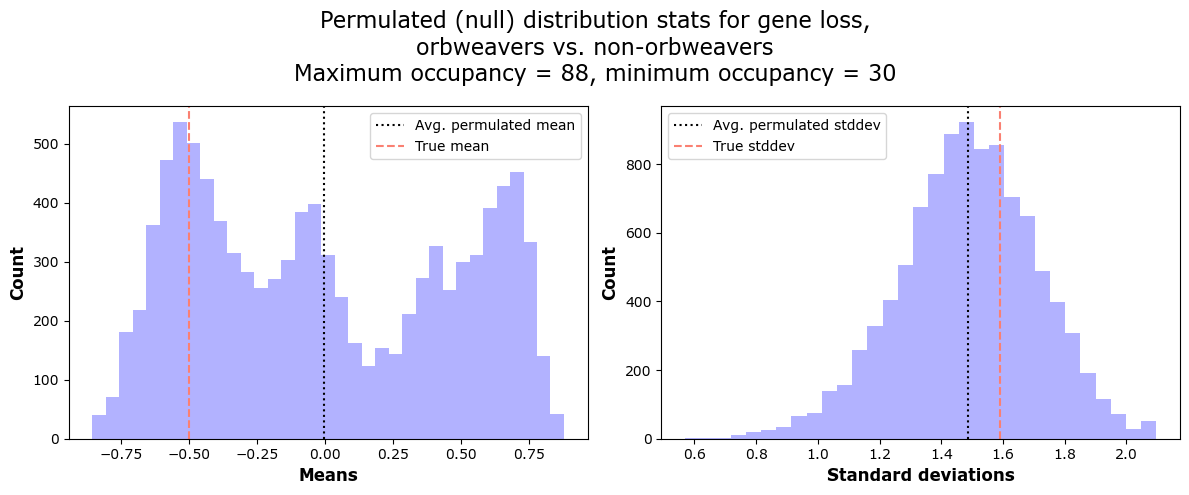

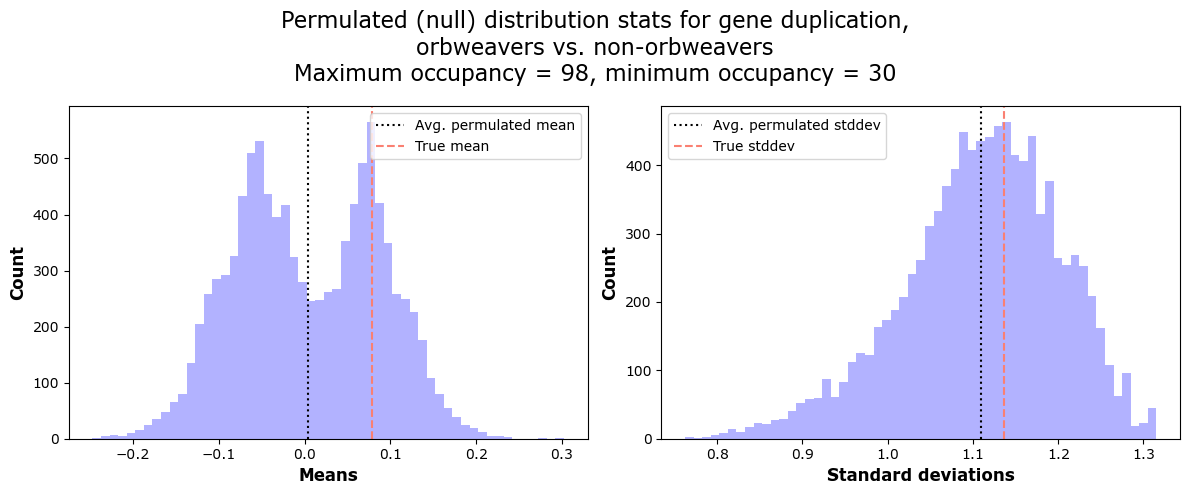

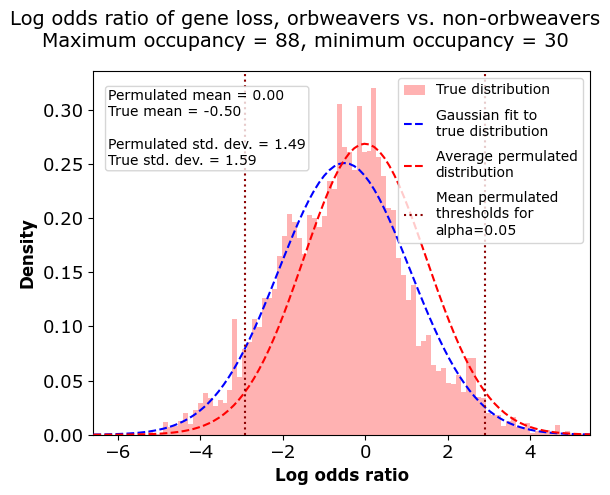

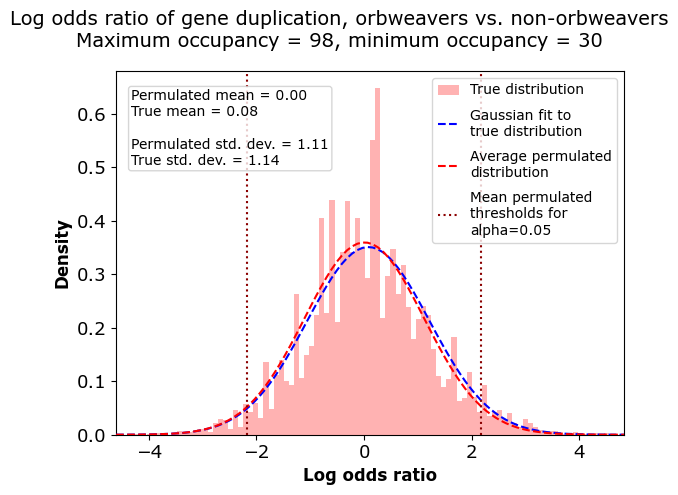

In [14]:
%autoreload 2
test = ort.odds_ratio_test(
    min_occ=30,
    max_occ=88,
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
    dir_suffix='all_orb'
)

save_pickle is set to False, so the full results object will not be saved as a pickle file.
To save the results object for future use, set save_pickle to True. If you stored the test 
results object in a variable, you can also save it as a pickle file using the `save_pickle_file`
method, e.g. 
my_results.save_pickle_file('path/to/save/my_results.pkl')
Wrote 410 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/loc_lists/loss_bg_sig_locs.txt
Wrote 272 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/loc_lists/dup_fg_sig_locs.txt
Wrote 153 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/loc_lists/loss_bg_sig_locs_avg_ci.txt
Wrote 65 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/loc_lists/dup_fg_sig_locs_avg_ci.txt
Generating universe LOCs...
Wrote 3950 items to /Us

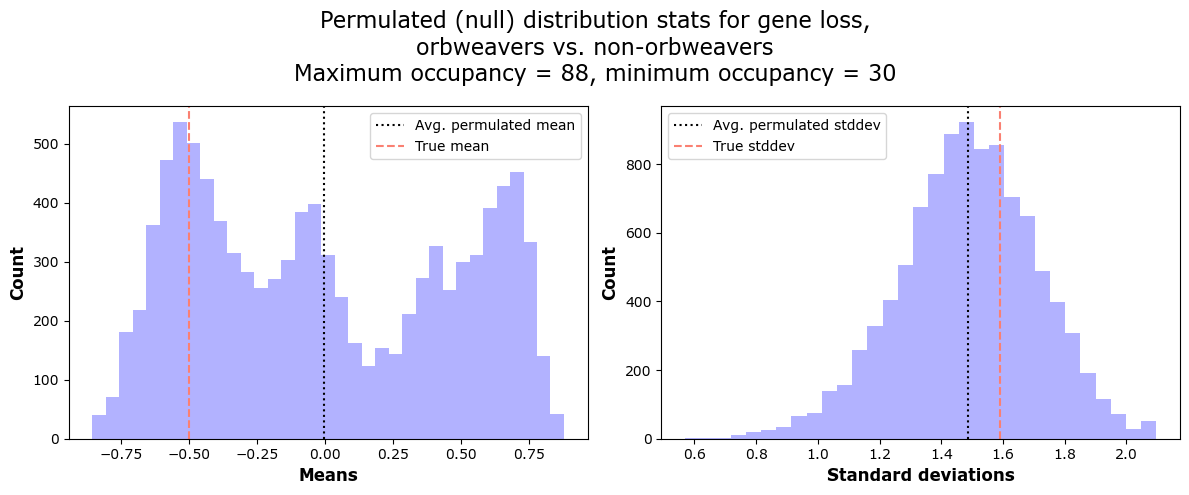

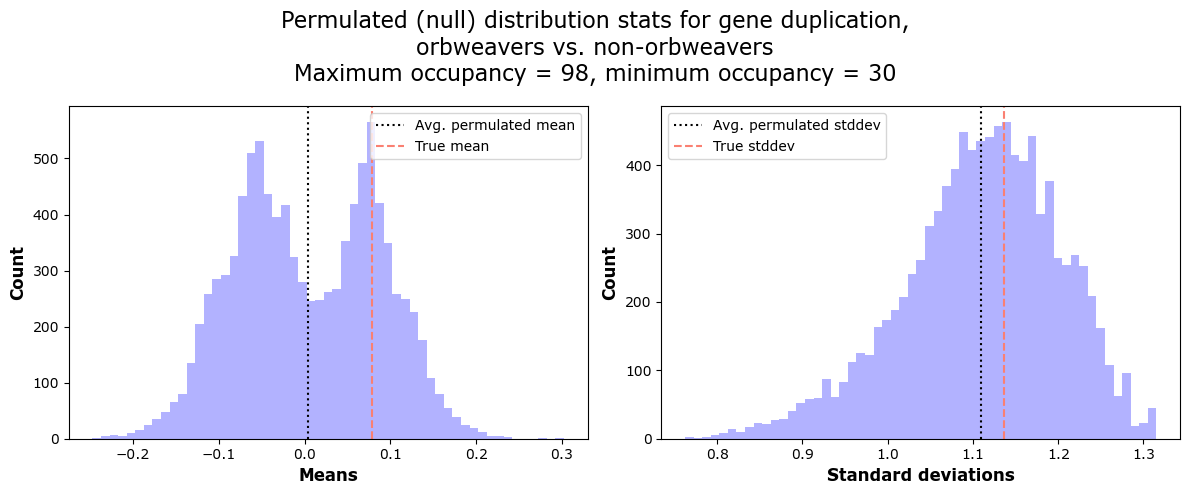

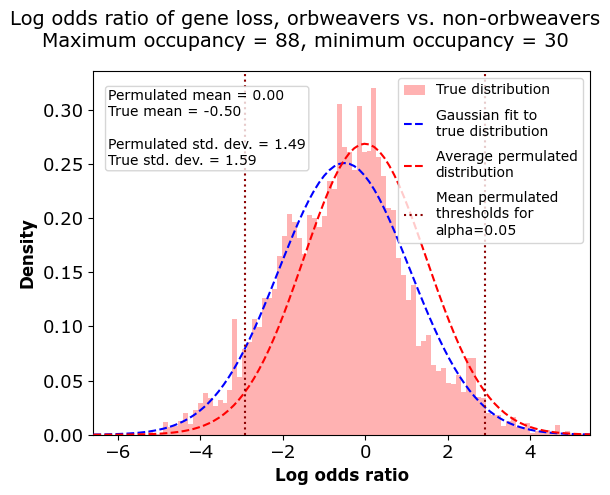

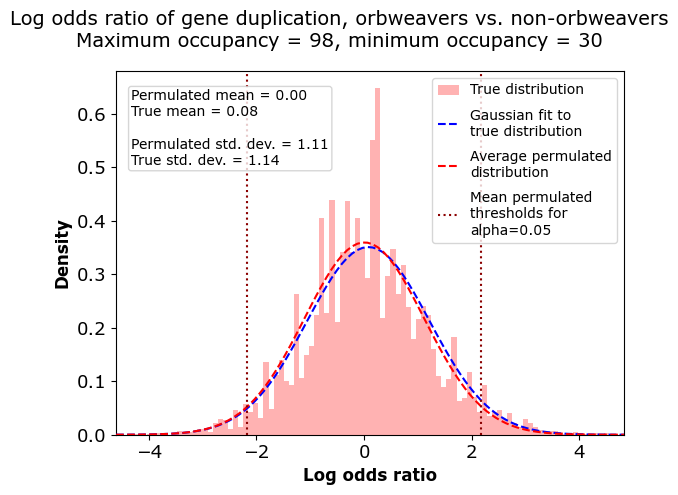

In [25]:
test.save_results_files(
    "/Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb", 
    save_pickle=False,
    fg_name='orbweavers',
    bg_name='non-orbweavers',)

## Without Araneids

68 species total, 17 foreground, 51 background
Log odds ratios of LOSS: 
 Mean: -0.34, Stddev: 1.72, Count of HOGs: 4634
Log odds ratios of DUPLICATION: 
 Mean: 0.23, Stddev: 1.11, Count of HOGs: 8837

LAUNCHING PERMULATION TEST

** Maximum occupancy set to 58 for loss test **
** Minimum occupancy set to 30 **

Using 10000 permulation-derived foreground/background assignments.


100%|██████████| 10000/10000 [04:32<00:00, 36.76it/s]


Permulation counter for MEANS:
 Loss: 4217, Duplication: 986
*********************** RESULTS ***********************

Permulation test with 10000 repetitions
Minimum occupancy: 30; max occupancy (loss): 58
Analysis run on 2026-04-16 at 14:34:39
Foreground list: /Users/calvin/orb-selection/data/orbweavers-list-no-araneids.txt
Background list: /Users/calvin/orb-selection/data/non-orb-weavers-no-araneids.txt
Gene count file: /Users/calvin/orb-selection/data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/data/N5.tsv
Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 4634 (loss), 8837 (duplication)
Total species: 68
Foreground count: 17
Background count: 51
True mean, loss: -0.340
True standard deviation, loss: 1.721
True mean, duplication: 0.232
True standard deviation, duplication: 1.108

** Permulation P-VALUES ** 

Probability that the null is true for MEAN, loss (alt=less): 0.422
Probability that the null is true for MEAN, 

PermulationTestResults(true_odds=OddsRatioResults(genecount_csv=/Users/calvin/orb-selection/data/N5.GeneCount.tsv, hog_node_genes_tsv=/Users/calvin/orb-selection/data/N5.tsv, foreground_list_filename=/Users/calvin/orb-selection/data/orbweavers-list-no-araneids.txt, background_list_filename=/Users/calvin/orb-selection/data/non-orb-weavers-no-araneids.txt), min_occ=30, permulation_reps=10000)

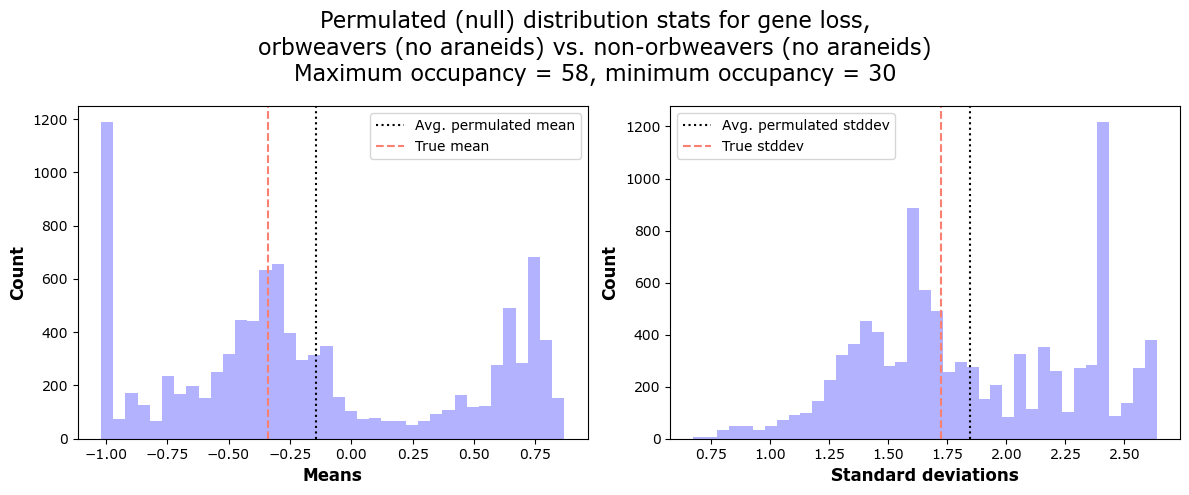

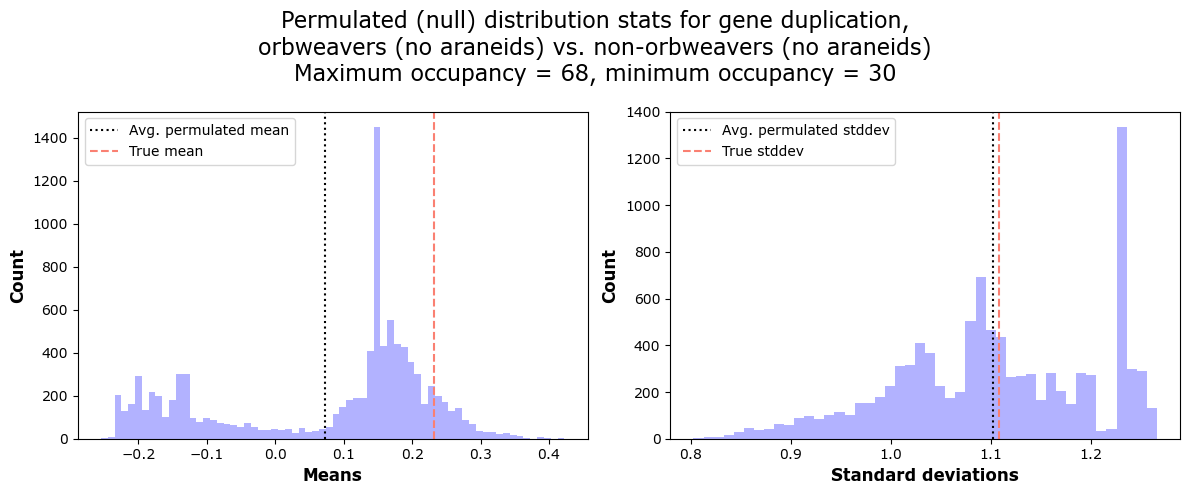

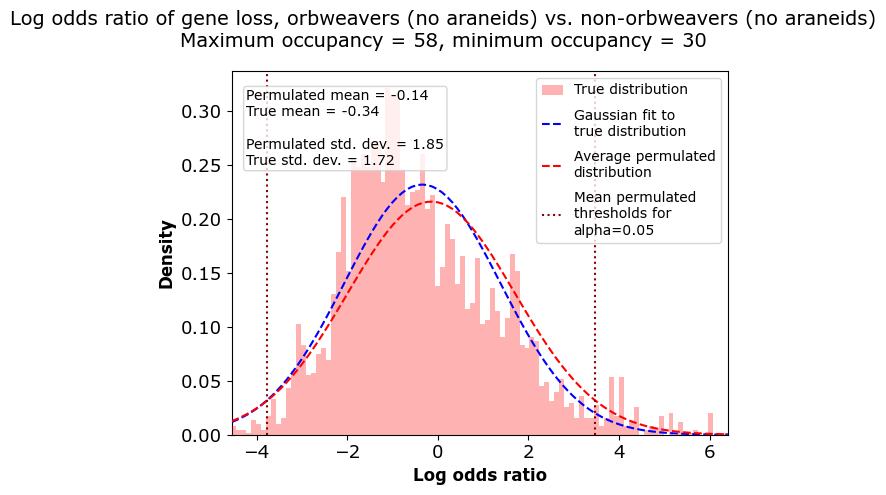

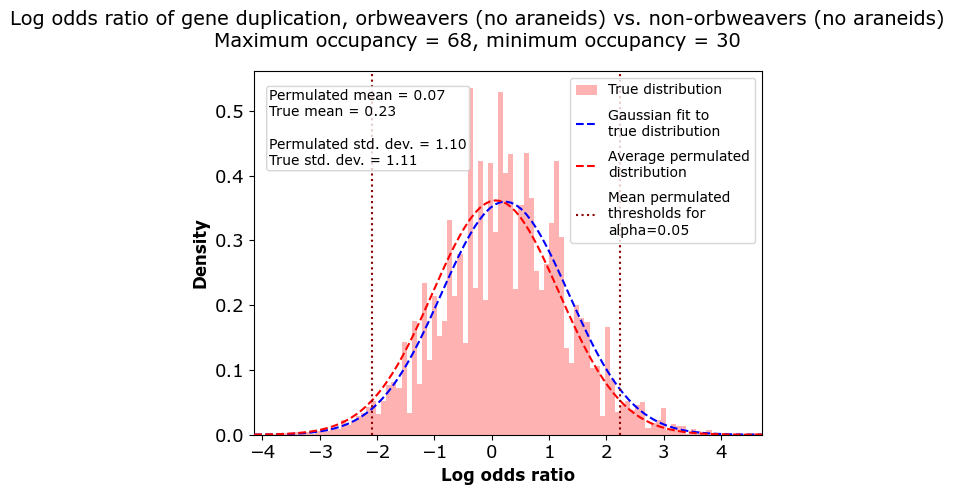

In [15]:
%autoreload 2
ort.odds_ratio_test(
    min_occ=30,
    max_occ=58,
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers (no araneids)',
    bg_name='non-orbweavers (no araneids)',
    foreground_list_filename="data/orbweavers-list-no-araneids.txt",
    background_list_filename="data/non-orb-weavers-no-araneids.txt",
    permulations_tip_values_csv="data/perms_tip_values_no_ara.csv",
    dir_suffix='no_ara'
)

## Without Tetragnathids

84 species total, 30 foreground, 54 background
Log odds ratios of LOSS: 
 Mean: -0.75, Stddev: 1.90, Count of HOGs: 6876
Log odds ratios of DUPLICATION: 
 Mean: 0.05, Stddev: 1.25, Count of HOGs: 10878

LAUNCHING PERMULATION TEST

** Maximum occupancy set to 74 for loss test **
** Minimum occupancy set to 30 **

Using 10000 permulation-derived foreground/background assignments.


100%|██████████| 10000/10000 [05:25<00:00, 30.71it/s]


Permulation counter for MEANS:
 Loss: 3945, Duplication: 3746
*********************** RESULTS ***********************

Permulation test with 10000 repetitions
Minimum occupancy: 30; max occupancy (loss): 74
Analysis run on 2026-04-16 at 14:39:40
Foreground list: /Users/calvin/orb-selection/data/orbweavers-list-no-tetragnathids.txt
Background list: /Users/calvin/orb-selection/data/non-orb-weavers-list.txt
Gene count file: /Users/calvin/orb-selection/data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/data/N5.tsv
Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 6876 (loss), 10878 (duplication)
Total species: 84
Foreground count: 30
Background count: 54
True mean, loss: -0.747
True standard deviation, loss: 1.900
True mean, duplication: 0.050
True standard deviation, duplication: 1.252

** Permulation P-VALUES ** 

Probability that the null is true for MEAN, loss (alt=less): 0.395
Probability that the null is true for MEAN, 

PermulationTestResults(true_odds=OddsRatioResults(genecount_csv=/Users/calvin/orb-selection/data/N5.GeneCount.tsv, hog_node_genes_tsv=/Users/calvin/orb-selection/data/N5.tsv, foreground_list_filename=/Users/calvin/orb-selection/data/orbweavers-list-no-tetragnathids.txt, background_list_filename=/Users/calvin/orb-selection/data/non-orb-weavers-list.txt), min_occ=30, permulation_reps=10000)

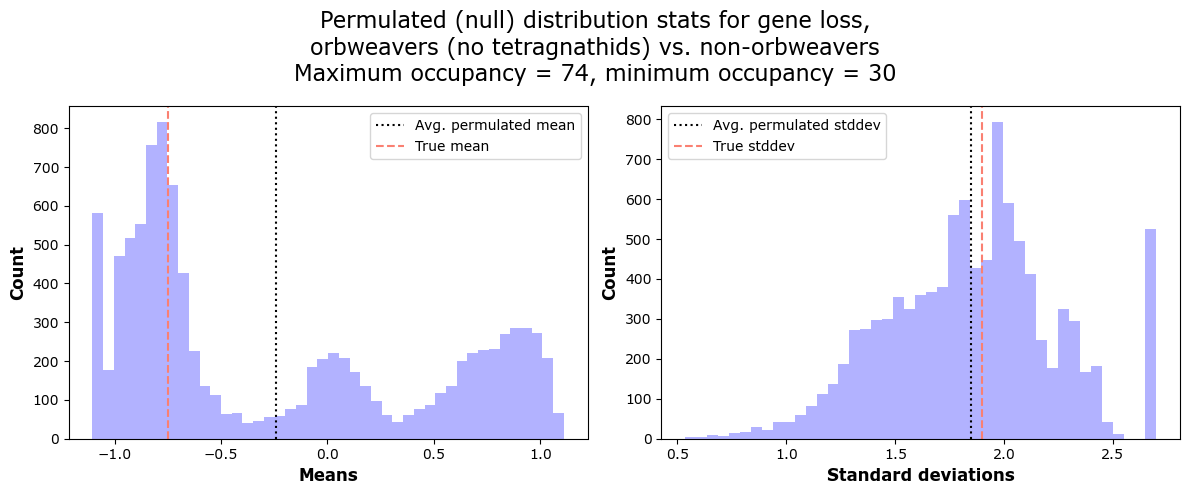

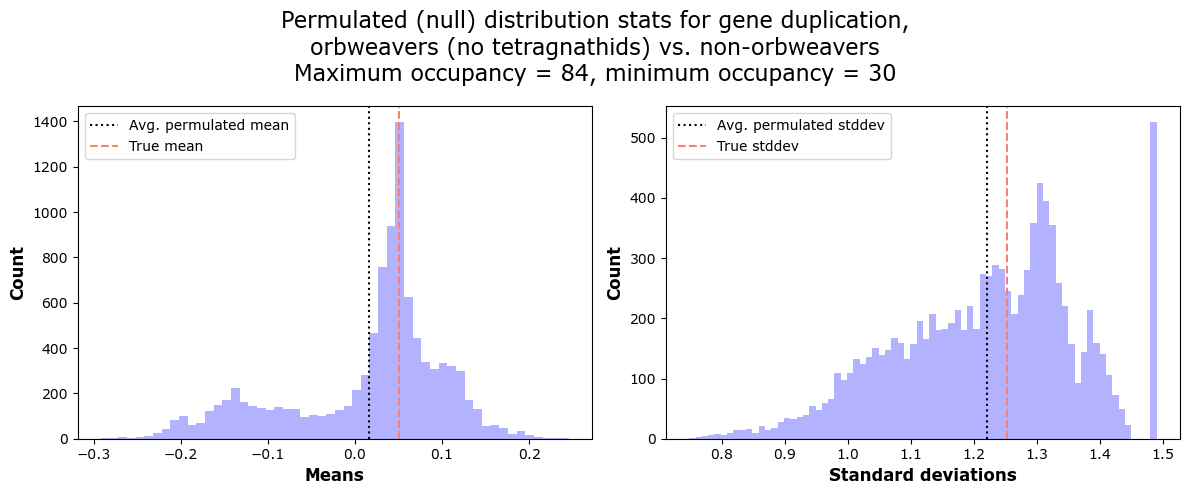

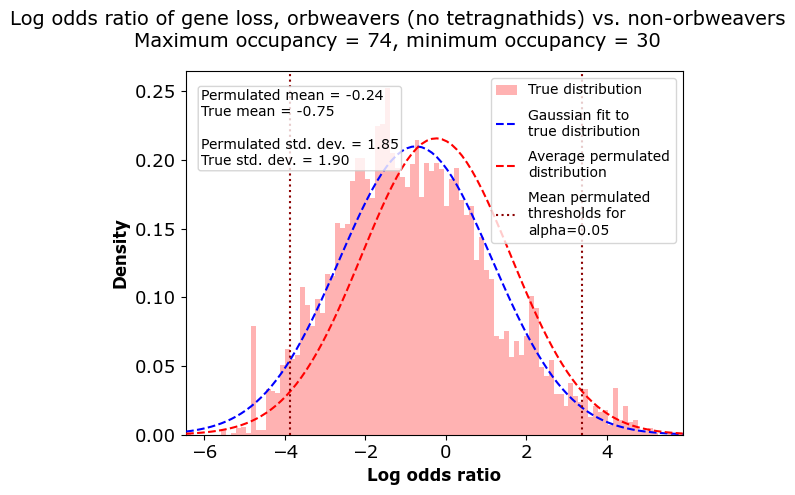

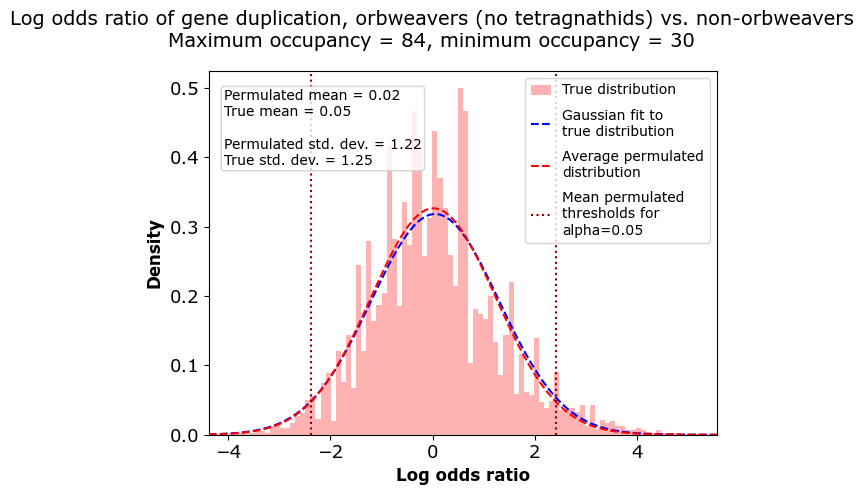

In [16]:
%autoreload 2
ort.odds_ratio_test(
    min_occ=30,
    max_occ=74,
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers (no tetragnathids)',
    bg_name='non-orbweavers',
    foreground_list_filename="data/orbweavers-list-no-tetragnathids.txt",
    background_list_filename="data/non-orb-weavers-list.txt",
    permulations_tip_values_csv="data/perms_tip_values_no_tet.csv",
    dir_suffix='no_tet'
)

In [19]:
%autoreload 2
results_all = ort.PermulationTestResults.load_from_pickle("results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/results.pkl")
_, counts1, run1_df, total_count1 = results_all.filter_for_permulation_hits()
run1_df.head()

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation
HOG,,,,,,,,,
N5.HOG0001041,46,2.2880419958817027,-0.2817346202540693,0.0038,0.9962,0.5328,0.4672,,loss_fg
N5.HOG0001609,49,-2.8415866828425416,2.3914853308298487,0.9605,0.0395,0.0747,0.9253,,loss_bg
N5.HOG0001627,33,2.048042501668181,-4.020456662035705,0.0449,0.9551,0.9745,0.0253,dup_bg,"loss_fg, dup_bg"
N5.HOG0002031,46,-3.8236010086737187,1.8546381292872387,0.9996,0.0004,0.3311,0.6686,loss_bg,loss_bg
N5.HOG0002072,52,3.473732866474442,-0.7627257209774443,0.0108,0.9892,0.7989,0.2011,loss_fg,loss_fg


In [20]:
counts1

{'loss_fg': 224, 'loss_bg': 529, 'dup_fg': 429, 'dup_bg': 383}

In [25]:
N5_count_df = results_all.true_odds.genecount_df.copy()
N5_count_df["occupancy"] = N5_count_df.select_dtypes(include="number").astype(
            "bool"
        ).sum(axis=1)
N5_count_df

,Acroaspis_sp_IDV6688,Acrosomoides_sp_IDV7426,Ainerigone_saitoi,Ambicodamus_IDV6680,Araneus_inustus,Arcuphantes_paiki,Arcuphantes_tamaensis,Arcuphantes_uenoi,Argiope_aetheroides,Argiope_bruennichi,...,Tetragnatha_quasimodo,Tetragnatha_stelarobusta,Tetragnatha_vermiformis,Tetragnatha_waikamoi,Tetragnatha_yesoensis,Theridion_varians,Uloborus_diversus,Ummeliata_osakaensis,Zelotes_iriomotensis,occupancy
HOG,,,,,,,,,,,,,,,,,,,,,
N5.HOG0000000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
N5.HOG0000001,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,0,0,0,0,23
N5.HOG0000002,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,9
N5.HOG0000003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
N5.HOG0000004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,3,0,0,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
N5.HOG0107981,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,1
N5.HOG0107982,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,1
N5.HOG0107983,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,1


In [30]:
dup_all_uni = N5_count_df[N5_count_df["occupancy"] >= results_all.min_occ].copy()

dup_all_uni.index

Index(['N5.HOG0000042', 'N5.HOG0000052', 'N5.HOG0000147', 'N5.HOG0000196',
       'N5.HOG0000276', 'N5.HOG0000428', 'N5.HOG0000526', 'N5.HOG0000608',
       'N5.HOG0000716', 'N5.HOG0001006',
       ...
       'N5.HOG0073590', 'N5.HOG0073630', 'N5.HOG0073702', 'N5.HOG0073709',
       'N5.HOG0073710', 'N5.HOG0073724', 'N5.HOG0073740', 'N5.HOG0073766',
       'N5.HOG0073773', 'N5.HOG0073818'],
      dtype='object', name='HOG', length=12096)

In [ ]:
import numpy as np
np.savetxt(
    "../../data/N5_hogs_min_occ_30.txt",
    dup_all_uni.index.values,
    fmt="%s",
)

In [28]:
%autoreload 2
results_no_ara = ort.PermulationTestResults.load_from_pickle(
    "results/odds_ratio_test/Results_Apr16/Run2_occ_30-58_10000x_no_ara/results.pkl"
)
run2_df = results_no_ara.results_fltrd_df_all
run2_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation
HOG,,,,,,,,,
N5.HOG0000196,30,-0.7505972168170153,2.9769124666242006,0.7434,0.2459,0.0475,0.9418,dup_fg,dup_fg
N5.HOG0001041,42,1.4126351796573566,0.6403643656316582,0.0243,0.9651,0.0728,0.9166,,loss_fg
N5.HOG0002054,52,-0.8702856695462228,1.8399655268541617,0.7859,0.2033,0.0496,0.9398,,dup_fg
N5.HOG0002072,48,3.3530805112801048,0.12441234415618349,0.0331,0.9563,0.3444,0.645,,loss_fg
N5.HOG0002083,38,-1.5393511114867557,2.9738324376044947,0.9351,0.0543,0.0216,0.9678,dup_fg,dup_fg
...,...,...,...,...,...,...,...,...,...
N5.HOG0072641,31,0.8808856621773117,0.13298990773975167,0.0425,0.9468,0.3134,0.6759,,loss_fg
N5.HOG0072712,33,0.37886670027811037,2.5876677529511163,0.3909,0.5984,0.0206,0.9688,dup_fg,dup_fg
N5.HOG0072790,32,-1.588656064082519,2.598171493915705,0.9697,0.0197,0.051,0.9382,,loss_bg


save_pickle is set to False, so the full results object will not be saved as a pickle file.
To save the results object for future use, set save_pickle to True. If you stored the test 
results object in a variable, you can also save it as a pickle file using the `save_pickle_file`
method, e.g. 
my_results.save_pickle_file('path/to/save/my_results.pkl')
Wrote 169 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run2_occ_30-58_10000x_no_ara/loc_lists/loss_bg_sig_locs.txt
Wrote 436 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run2_occ_30-58_10000x_no_ara/loc_lists/dup_fg_sig_locs.txt
Wrote 28 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run2_occ_30-58_10000x_no_ara/loc_lists/loss_bg_sig_locs_avg_ci.txt
Wrote 120 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run2_occ_30-58_10000x_no_ara/loc_lists/dup_fg_sig_locs_avg_ci.txt
Generating universe LOCs...
Wrote 2717 items to /Users/

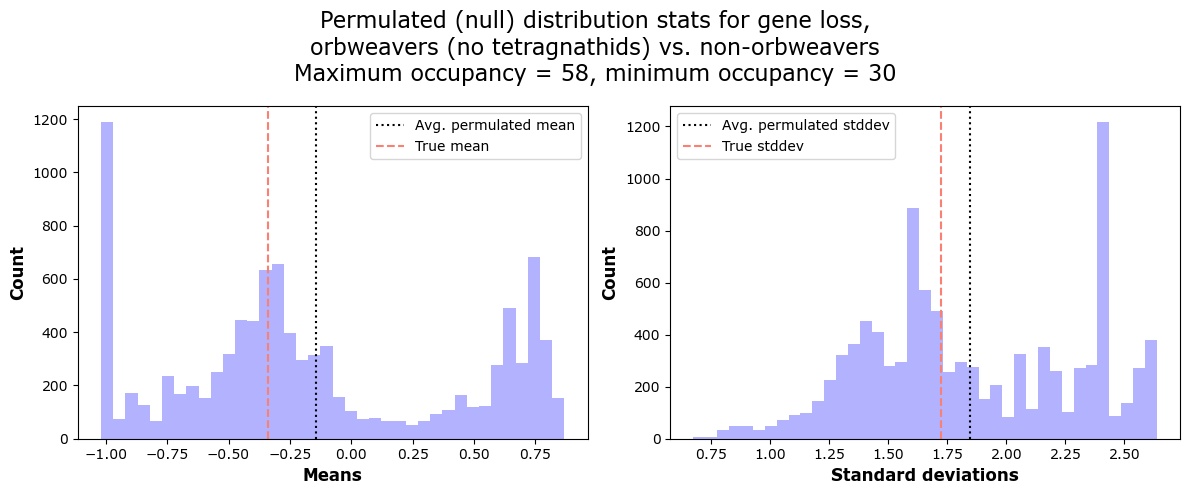

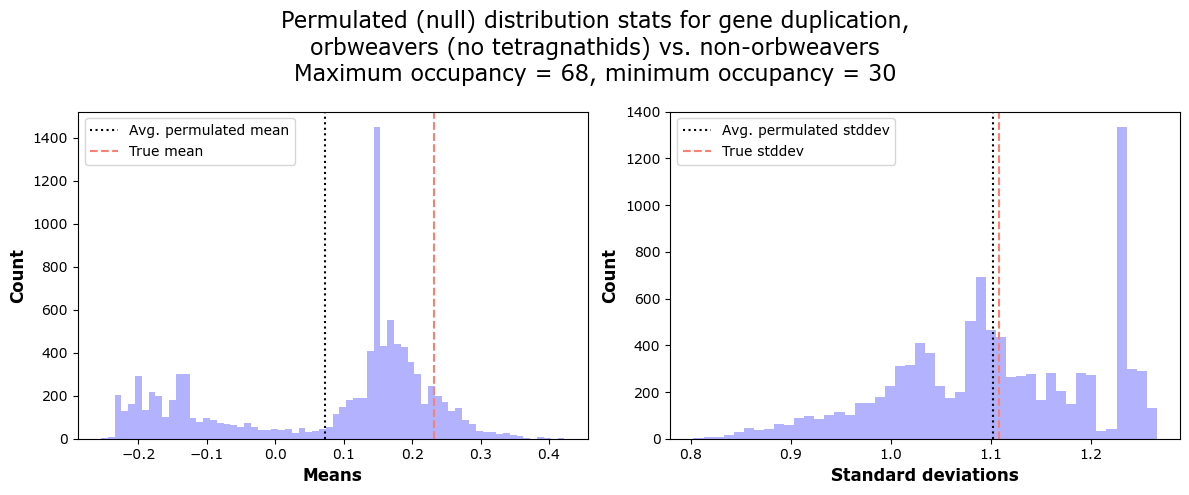

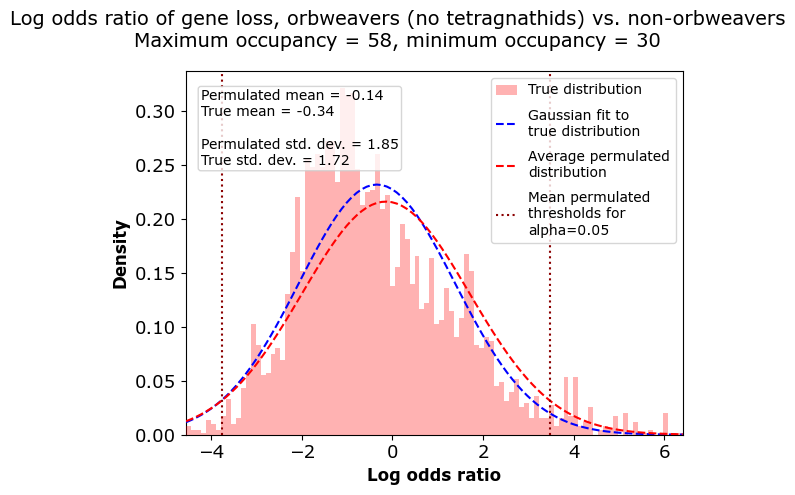

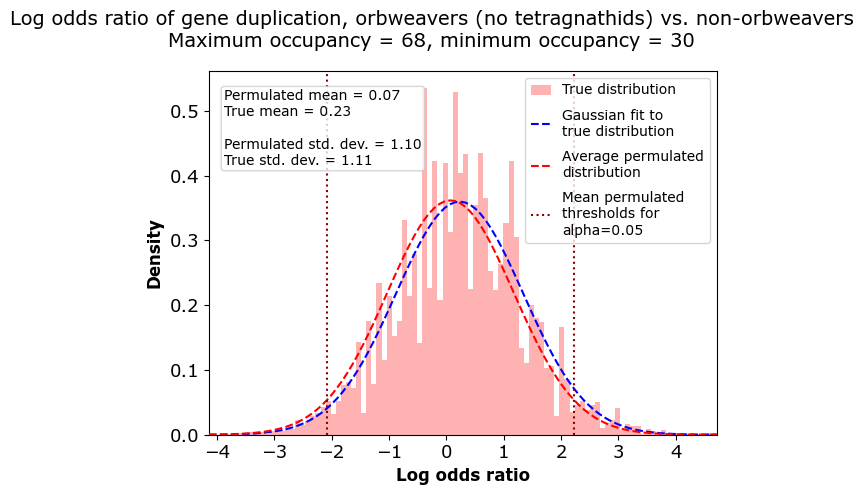

In [29]:
results_no_ara.save_results_files(
    "/Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run2_occ_30-58_10000x_no_ara", 
    save_pickle=False,
    fg_name='orbweavers (no tetragnathids)',
    bg_name='non-orbweavers',
    )

In [26]:
%autoreload 2
results_no_tet = ort.PermulationTestResults.load_from_pickle(
    "results/odds_ratio_test/Results_Apr16/Run3_occ_30-74_10000x_no_tet/results.pkl"
)
run3_df = results_no_tet.results_fltrd_df_all
run3_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation
HOG,,,,,,,,,
N5.HOG0000608,78,-2.0241914773979355,-0.9680713054175893,0.8184,0.1814,0.9614,0.0386,,dup_bg
N5.HOG0001041,40,3.2632296405600383,-0.8571698677179824,0.001,0.999,0.7992,0.2008,,loss_fg
N5.HOG0001051,58,-0.801149059512612,-0.8996451340414386,0.9149,0.0851,0.951,0.049,,dup_bg
N5.HOG0002031,32,-3.3817163232778666,0.5673996668294717,0.9977,0.0023,0.5277,0.4723,,loss_bg
N5.HOG0002076,48,-2.9351990748755923,0.8607508368928413,0.997,0.003,0.1829,0.8171,,loss_bg
...,...,...,...,...,...,...,...,...,...
N5.HOG0072992,34,-1.6841509251972446,0.5499430712461646,0.9783,0.0217,0.4481,0.5519,,loss_bg
N5.HOG0072994,32,-3.387542890339417,0.2628867252812254,0.9954,0.0046,0.3626,0.6374,,loss_bg
N5.HOG0072997,31,-0.6260384836857579,1.499367828413793,0.967,0.033,0.0431,0.9569,,"loss_bg, dup_fg"


save_pickle is set to False, so the full results object will not be saved as a pickle file.
To save the results object for future use, set save_pickle to True. If you stored the test 
results object in a variable, you can also save it as a pickle file using the `save_pickle_file`
method, e.g. 
my_results.save_pickle_file('path/to/save/my_results.pkl')
Wrote 258 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run3_occ_30-74_10000x_no_tet/loc_lists/loss_bg_sig_locs.txt
Wrote 199 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run3_occ_30-74_10000x_no_tet/loc_lists/dup_fg_sig_locs.txt
Wrote 33 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run3_occ_30-74_10000x_no_tet/loc_lists/loss_bg_sig_locs_avg_ci.txt
Wrote 33 items to /Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run3_occ_30-74_10000x_no_tet/loc_lists/dup_fg_sig_locs_avg_ci.txt
Generating universe LOCs...
Wrote 3350 items to /Users/c

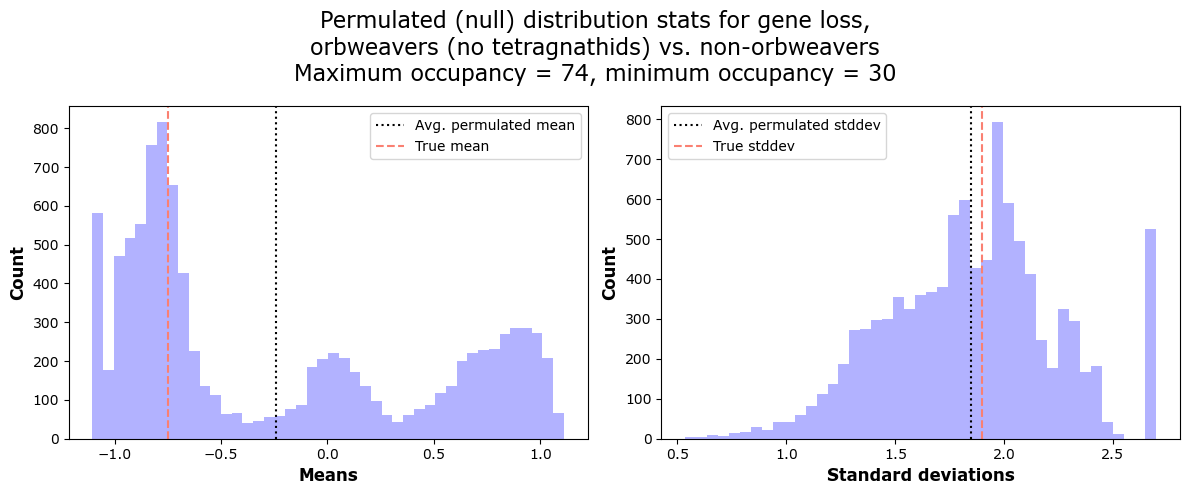

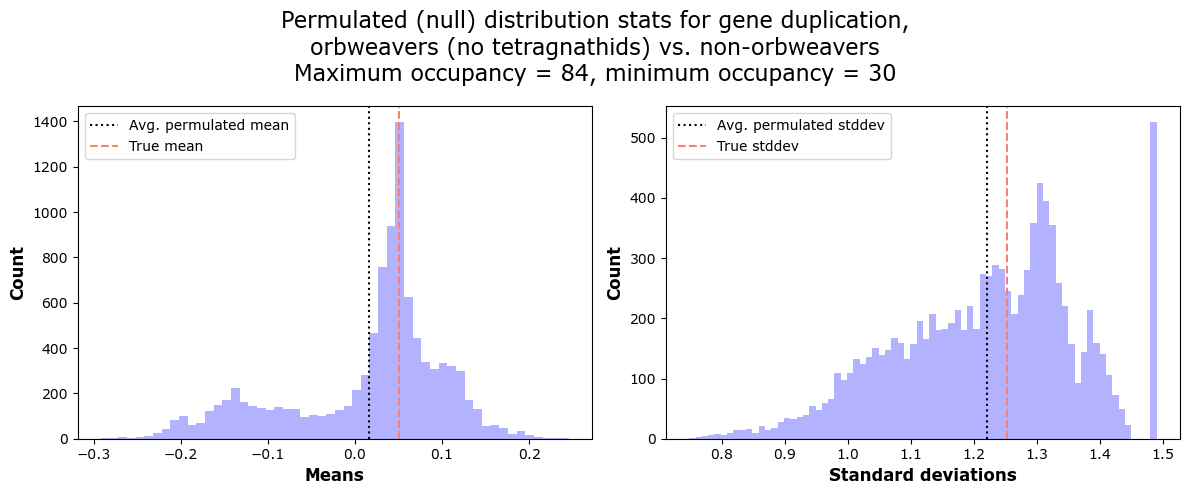

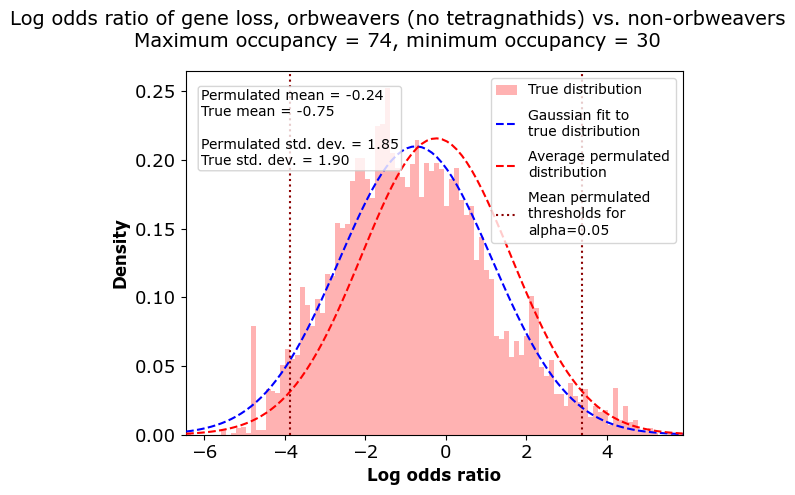

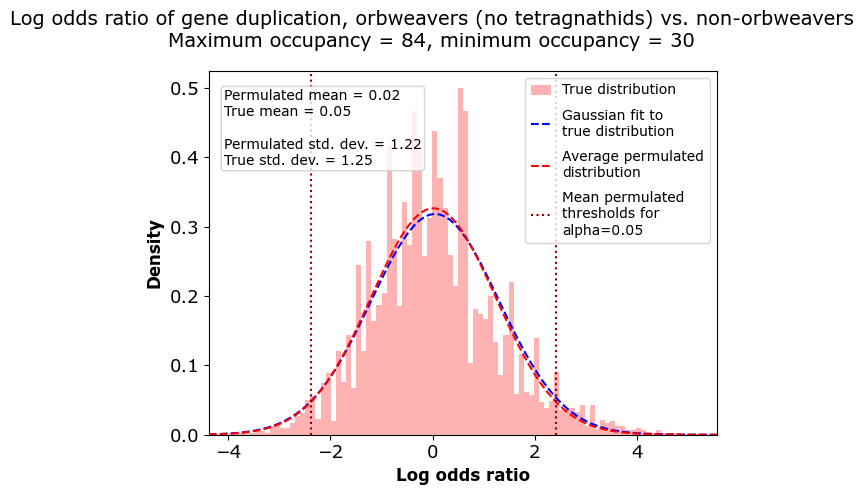

In [27]:
results_no_tet.save_results_files(
    "/Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr16/Run3_occ_30-74_10000x_no_tet", 
    save_pickle=False,
    fg_name='orbweavers (no tetragnathids)',
    bg_name='non-orbweavers',
    )

In [22]:
common_hogs = run1_df.index.intersection(run2_df.index).intersection(run3_df.index)
intersection_df = run1_df.loc[common_hogs]
intersection_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test
HOG,,,,,,,,
N5.HOG0002072,52,3.473733,-0.762726,0.0108,0.9892,0.7989,0.2011,True
N5.HOG0007439,30,4.648890,-3.478649,0.0025,0.9975,0.9640,0.0359,True
N5.HOG0010634,55,4.393024,-1.824667,0.0855,0.9145,0.8897,0.1103,False
N5.HOG0012951,42,4.427061,-3.392096,0.0438,0.9562,0.9630,0.0369,True
N5.HOG0012963,34,4.923012,-2.391483,0.0048,0.9952,0.9056,0.0941,True
...,...,...,...,...,...,...,...,...
N5.HOG0062680,98,0.207736,-3.113861,0.4018,0.5981,0.9679,0.0320,True
N5.HOG0063867,83,2.825520,-2.917895,0.1753,0.8247,0.9623,0.0376,True
N5.HOG0067099,56,2.637281,-2.916448,0.0624,0.9376,0.9541,0.0458,True


In [23]:
run1_df_fltrd = run1_df[
    run1_df["Significant in permulation test"]
]
run2_df_fltrd = run2_df[
    run2_df["Significant in permulation test"]
]
run3_df_fltrd = run3_df[
    run3_df["Significant in permulation test"]
]

common_hogs_fltrd = run1_df_fltrd.index.intersection(run2_df_fltrd.index).intersection(run3_df_fltrd.index)
intersection_df_fltrd = run1_df_fltrd.loc[common_hogs_fltrd]
intersection_df_fltrd

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant in permulation test
HOG,,,,,,,,
N5.HOG0007439,30,4.648890,-3.478649,0.0025,0.9975,0.9640,0.0359,True
N5.HOG0012963,34,4.923012,-2.391483,0.0048,0.9952,0.9056,0.0941,True
N5.HOG0022325,34,3.812024,-3.426032,0.0075,0.9925,0.9656,0.0343,True
N5.HOG0033305,33,4.870321,-3.217480,0.0076,0.9924,0.9439,0.0559,True
N5.HOG0036007,31,4.719117,-1.588599,0.0065,0.9935,0.8698,0.1301,True
N5.HOG0043760,35,5.023451,-3.020487,0.0046,0.9954,0.9393,0.0603,True
N5.HOG0043831,30,4.644039,-1.832478,0.0113,0.9887,0.8984,0.1016,True
N5.HOG0047981,33,4.863396,-3.558733,0.0044,0.9956,0.9581,0.0418,True
N5.HOG0048549,61,4.353531,-1.561977,0.0001,0.9999,0.9176,0.0824,True


Of interest: innexin, slit, osteopetrosis-associated transmembrane protein (nervous), pantetheinase (oxidative stress)

Makes sense that the ones that are more likely lost in orb-weavers and more likely duplicated in non-orb-weavers are unannotated in U.div! Maybe I should annotate them using a non-orb-weaver genome

In [24]:
convert_hogs_to_locs(intersection_df, results_all.true_odds.hog_node_genes_tsv)

Processing HOGs:   0%|          | 0/142 [00:00<?, ?it/s]


ValueError: Must have equal len keys and value when setting with an iterable